# **Data** **Understanding**

## **Collect Initial Data**

### Data Extraction from BigQuery

In this step, data is extracted from the public GitHub Archive dataset using Google BigQuery.

The goal is to:

- Select repositories with sufficient activity and engagement  
- Construct repository-level activity features for modeling  
- Collect fork and pull request events for conversion analysis  

All queries were executed in BigQuery, and results were stored as intermediate tables:

- `activity_sample`  
- `fork_pr_sample`  

The queries below represent the final data extraction and preparation pipeline used for further analysis.


#### Activity sample Table

This query constructs a repository-level feature table for modeling.

For each repository and season (*winter_spring*, *summer_autumn*), it computes:

- Number of watches (stars)  
- Number of pushes  
- Number of issues  
- Number of issue comments  
- Number of releases  

Additionally, the query:

- Restricts activity to fixed 3-month windows (Jan–Mar, Jul–Sep) to align with the modeling setup  
- Aggregates all activity metrics at the repository–season level  
- Filters repositories with at least 5 forks to remove low-signal cases  
- Ensures repositories have at least some activity (non-zero engagement)  
- Randomly samples up to 100,000 repository–season pairs to control data volume  

The resulting table represents the feature space used for modeling.




```sql
CREATE OR REPLACE TABLE `data-mining-project-493709.github.activity_sample` AS

WITH base_events AS (
  SELECT
    repo.name AS repo_name,
    actor.login AS user_login,
    repo.url AS repo_url,
    type AS event_type,
    TIMESTAMP(created_at) AS event_time,
    _TABLE_SUFFIX AS month,
    public
  FROM `githubarchive.month.2025*`
  WHERE _TABLE_SUFFIX IN ('01','02','03','07','08','09')
    AND type IN (
      'ForkEvent',
      'WatchEvent',
      'PushEvent',
      'IssuesEvent',
      'IssueCommentEvent',
      'ReleaseEvent'
    )
),

events_with_season AS (
  SELECT *,
    CASE
      WHEN month IN ('01','02','03') THEN 'winter_spring'
      WHEN month IN ('07','08','09') THEN 'summer_autumn'
    END AS season
  FROM base_events
),

fork_counts AS (
  SELECT
    repo_name,
    season,
    COUNT(*) AS forks_cnt
  FROM events_with_season
  WHERE event_type = 'ForkEvent'
  GROUP BY repo_name, season
),

activity_agg AS (
  SELECT
    repo_name,
    season,

    ANY_VALUE(repo_url) AS repo_url,
    ANY_VALUE(public) AS public,

    COUNTIF(event_type = 'WatchEvent') AS watches,
    COUNTIF(event_type = 'PushEvent') AS pushes,
    COUNTIF(event_type = 'IssuesEvent') AS issues,
    COUNTIF(event_type = 'IssueCommentEvent') AS issue_comments,
    COUNTIF(event_type = 'ReleaseEvent') AS releases

  FROM events_with_season
  GROUP BY repo_name, season
),

repo_sample AS (
  SELECT f.repo_name, f.season
  FROM fork_counts f
  JOIN activity_agg a
    ON f.repo_name = a.repo_name
    AND f.season = a.season
  WHERE
    f.forks_cnt > 5
    AND (
      a.watches > 0 OR
      a.pushes > 0 OR
      a.issues > 0 OR
      a.issue_comments > 0 OR
      a.releases > 0
    )
  ORDER BY RAND()
  LIMIT 100000
)

SELECT
  a.repo_name,
  a.season,
  a.repo_url,
  a.public,

  a.watches,
  a.pushes,
  a.issues,
  a.issue_comments,
  a.releases

FROM repo_sample r
JOIN activity_agg a
  ON r.repo_name = a.repo_name
  AND r.season = a.season
```



#### Forks & Pull Requests sampled table

This query constructs the event-level structure required to compute conversion outcomes.

For each repository and season, it builds:

- An array of fork events, each containing:
  - user identifier  
  - timestamp  
  - event type (fork)  

- An array of pull request events, each containing:
  - user identifier  
  - timestamp  
  - event type (pr)  

The query applies the following logic:

- Fork events are restricted to the anchor periods (Jan–Mar, Jul–Sep)  
- Pull request events are collected within extended seasonal windows (Jan–Jun, Jul–Dec), allowing time for contributions after fork activity  
- Pull requests are aggregated at the repository–season level rather than matched to individual forks  
- Only repositories present in the sampled activity table are included, ensuring consistency between features and targets  

The resulting table provides the event structure required for target construction, enabling analysis of how repository activity relates to subsequent contribution behavior.

```sql
CREATE OR REPLACE TABLE `data-mining-project-493709.github.fork_pr_sample` AS

WITH raw_events AS (
  SELECT
    repo.name AS repo_name,
    actor.login AS user_login,
    type AS event_type,
    TIMESTAMP(created_at) AS event_time,
    _TABLE_SUFFIX AS month
  FROM `githubarchive.month.2025*`
  WHERE type IN ('ForkEvent', 'PullRequestEvent')
),

forks AS (
  SELECT
    repo_name, user_login, event_time,
    CASE
      WHEN month IN ('01','02','03') THEN 'winter_spring'
      WHEN month IN ('07','08','09') THEN 'summer_autumn'
    END AS season
  FROM raw_events
  WHERE event_type = 'ForkEvent' AND month IN ('01','02','03','07','08','09')
),

prs AS (
  SELECT
    repo_name, user_login, event_time,
    CASE
      WHEN month IN ('01','02','03','04','05','06') THEN 'winter_spring'
      WHEN month IN ('07','08','09','10','11','12') THEN 'summer_autumn'
    END AS season
  FROM raw_events
  WHERE event_type = 'PullRequestEvent'
),

prs_agg AS (
  SELECT
    repo_name, season,
    ARRAY_AGG(STRUCT(user_login, event_time, 'pr' AS type)) AS prs_list
  FROM prs
  GROUP BY 1, 2
)

SELECT
  f.repo_name,
  f.season,
  ARRAY_AGG(STRUCT(f.user_login, f.event_time, 'fork' AS type)) AS forks,
  ANY_VALUE(p.prs_list) AS prs
FROM forks f
JOIN `data-mining-project-493709.github.activity_sample` a ON f.repo_name = a.repo_name AND f.season = a.season
LEFT JOIN prs_agg p ON f.repo_name = p.repo_name AND f.season = p.season
GROUP BY 1, 2

```



### Load Data into Colab

In [ ]:
import pandas as pd
from google.colab import auth
auth.authenticate_user()

MY_PROJECT_ID = 'data-mining-project-493709'

tables = ['fork_pr_sample', 'activity_sample']

for table_name in tables:
    print(f'Loading {table_name}...')
    sql = f"SELECT * FROM `github.{table_name}`"

    df = pd.read_gbq(sql, project_id=MY_PROJECT_ID, dialect='standard', progress_bar_type='tqdm')

    file_name = f'{table_name}.parquet'
    df.to_parquet(file_name, index=False)
    print(f'Done! {file_name} was created')



Loading fork_pr_sample...


/tmp/ipykernel_7167/2304214017.py:13: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(sql, project_id=MY_PROJECT_ID, dialect='standard', progress_bar_type='tqdm')


Downloading: 100%|██████████|
Done! fork_pr_sample.parquet was created
Loading activity_sample...


/tmp/ipykernel_7167/2304214017.py:13: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(sql, project_id=MY_PROJECT_ID, dialect='standard', progress_bar_type='tqdm')


Downloading: 100%|██████████|
Done! activity_sample.parquet was created


## **Describe Data**

### Load Data

In this step, we load the extracted datasets into the Python environment for inspection.

In [129]:
import pandas as pd

activity = pd.read_parquet('data/activity_sample.parquet')
fork_pr = pd.read_parquet('data/fork_pr_sample.parquet')

### Data Format

We inspect the data types of each column to understand the structure and format of the datasets.
The activity table contains repository-level engagement metrics, including watches, pushes, issues, issue comments, and releases.

In [130]:
print("Activity dtypes:")
print(activity.dtypes)

print("\nFork/PR dtypes:")
print(fork_pr.dtypes)

Activity dtypes:
repo_name          object
season             object
repo_url           object
public            boolean
watches             Int64
pushes              Int64
issues              Int64
issue_comments      Int64
releases            Int64
dtype: object

Fork/PR dtypes:
repo_name    object
season       object
forks        object
prs          object
dtype: object


### Data Size

We examine the number of rows and columns in each dataset to understand the scale of the data.


In [131]:
print("Activity shape:", activity.shape)
print("Fork/PR shape:", fork_pr.shape)

Activity shape: (100000, 9)
Fork/PR shape: (100000, 4)


### Field Names

We list all column names to identify the available features in each dataset.

In [132]:
print("Activity columns:")
print(activity.columns.tolist())

print("\nFork/PR columns:")
print(fork_pr.columns.tolist())

Activity columns:
['repo_name', 'season', 'repo_url', 'public', 'watches', 'pushes', 'issues', 'issue_comments', 'releases']

Fork/PR columns:
['repo_name', 'season', 'forks', 'prs']


### Table Structure Overview

We use `.info()` to summarize column types, non-null counts, and memory usage.

In [133]:
print("Activity info:")
activity.info()

print("\nFork/PR info:")
fork_pr.info()

Activity info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   repo_name       100000 non-null  object 
 1   season          100000 non-null  object 
 2   repo_url        100000 non-null  object 
 3   public          100000 non-null  boolean
 4   watches         100000 non-null  Int64  
 5   pushes          100000 non-null  Int64  
 6   issues          100000 non-null  Int64  
 7   issue_comments  100000 non-null  Int64  
 8   releases        100000 non-null  Int64  
dtypes: Int64(5), boolean(1), object(3)
memory usage: 6.8+ MB

Fork/PR info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   repo_name  100000 non-null  object
 1   season     100000 non-null  object
 2   forks      100000 n

In [134]:
activity.head()

,repo_name,season,repo_url,public,watches,pushes,issues,issue_comments,releases
0,GoodRequest/BackendAssignment-Fitness,winter_spring,https://api.github.com/repos/GoodRequest/Backe...,True,0,1,0,0,0
1,NREL/DE,winter_spring,https://api.github.com/repos/NREL/DE,True,0,1,0,0,0
2,danhpaiva/class-psc-algorithm-00,summer_autumn,https://api.github.com/repos/danhpaiva/class-p...,True,0,1,0,0,0
3,NaturalCoder/TI96,winter_spring,https://api.github.com/repos/NaturalCoder/TI96,True,0,25,0,0,0
4,josedom24/ic-html5,winter_spring,https://api.github.com/repos/josedom24/ic-html5,True,0,2,0,0,0


In [135]:
fork_pr.head()

,repo_name,season,forks,prs
0,Quitten/Autorize,summer_autumn,"[{'event_time': 2025-09-13 12:19:55+00:00, 'ty...","[{'event_time': 2025-09-01 19:31:59+00:00, 'ty..."
1,imzyb/MiSub,summer_autumn,"[{'event_time': 2025-09-05 07:39:27+00:00, 'ty...","[{'event_time': 2025-11-01 07:20:49+00:00, 'ty..."
2,facebookresearch/pytorch3d,summer_autumn,"[{'event_time': 2025-09-22 18:15:37+00:00, 'ty...","[{'event_time': 2025-08-01 14:46:39+00:00, 'ty..."
3,meltylabs/melty,summer_autumn,"[{'event_time': 2025-08-17 20:25:43+00:00, 'ty...",[]
4,GouvernementFR/dsfr,summer_autumn,"[{'event_time': 2025-09-01 14:44:37+00:00, 'ty...","[{'event_time': 2025-11-20 15:32:26+00:00, 'ty..."


### Memory Usage

We estimate memory consumption to understand dataset size in the local environment.

In [136]:
print("Activity memory (MB):", activity.memory_usage(deep=True).sum() / 1e6)
print("Fork/PR memory (MB):", fork_pr.memory_usage(deep=True).sum() / 1e6)

Activity memory (MB): 28.677304
Fork/PR memory (MB): 37.638718


## **Explore Data**

### Distribution of Activity Metrics
We analyze the distribution of key repository activity metrics:
- watches (stars)
- pushes
- issues
- issue comments
- releases

In [137]:
activity[['watches', 'pushes', 'issues', 'issue_comments', 'releases']].describe()



,watches,pushes,issues,issue_comments,releases
count,100000.0,100000.0,100000.0,100000.0,100000.0
mean,120.74381,86.50863,21.31685,78.83938,1.95909
std,676.692394,1359.363454,240.586278,971.744721,22.006616
min,0.0,0.0,0.0,0.0,0.0
25%,6.0,0.0,0.0,0.0,0.0
50%,27.0,4.0,1.0,2.0,0.0
75%,87.0,28.0,9.0,24.0,0.0
max,79049.0,340799.0,48592.0,199042.0,2143.0


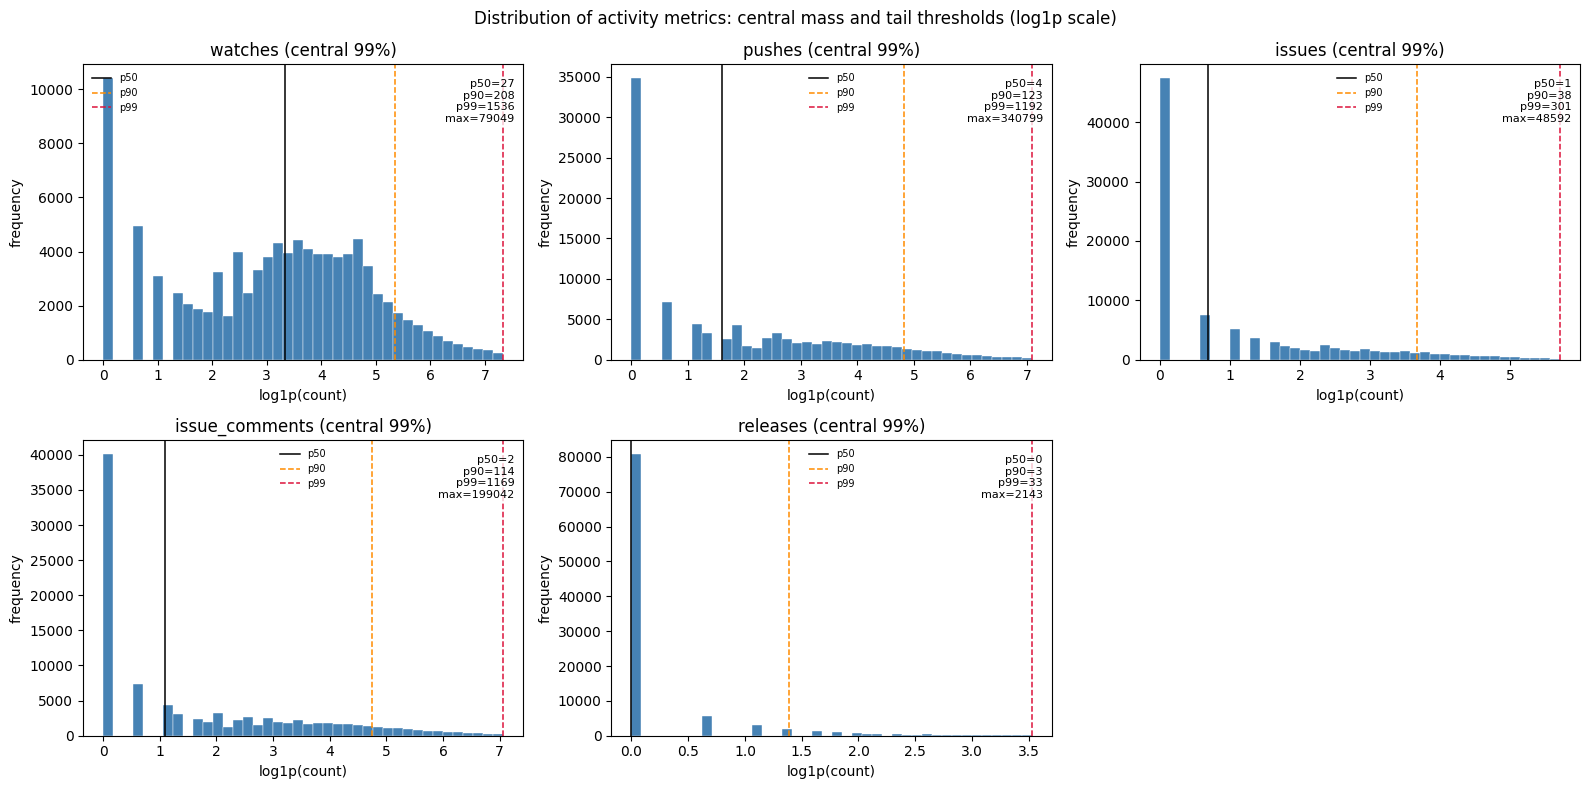

In [138]:
import matplotlib.pyplot as plt
import numpy as np

features = ['watches', 'pushes', 'issues', 'issue_comments', 'releases']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for i, col in enumerate(features):
    ax = axes.flat[i]

    values = activity[col].astype(float).dropna()
    x = np.log1p(values)

    q50 = np.quantile(x, 0.50)
    q90 = np.quantile(x, 0.90)
    q99 = np.quantile(x, 0.99)
    x_central = x[x <= q99]  # hide top 1% so the central distribution is readable

    ax.hist(x_central, bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(q50, color='black', linestyle='-', linewidth=1.1, label='p50')
    ax.axvline(q90, color='darkorange', linestyle='--', linewidth=1.1, label='p90')
    ax.axvline(q99, color='crimson', linestyle='--', linewidth=1.1, label='p99')

    ax.set_title(f"{col} (central 99%)")
    ax.set_xlabel('log1p(count)')
    ax.set_ylabel('frequency')
    ax.legend(frameon=False, fontsize=7)

    ax.text(
        0.98,
        0.95,
        f"p50={np.expm1(q50):.0f}\np90={np.expm1(q90):.0f}\np99={np.expm1(q99):.0f}\nmax={values.max():.0f}",
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none')
    )

axes.flat[-1].axis('off')
fig.suptitle('Distribution of activity metrics: central mass and tail thresholds (log1p scale)')
plt.tight_layout()
plt.show()

We observe the presence of extreme outliers in activity metrics.
We identify repositories with unusually high values.

In [139]:
high_activity = activity[
    (activity['watches'] >= 3000) |
    (activity['pushes'] >= 6000) |
    (activity['issues'] >= 2000) |
    (activity['issue_comments'] >= 4000) |
    (activity['releases'] >= 40)
]
print("Number of high-activity repos:", len(high_activity))
high_activity[['watches','pushes','issues', 'issue_comments', 'releases']].describe()

Number of high-activity repos: 1476


,watches,pushes,issues,issue_comments,releases
count,1476.0,1476.0,1476.0,1476.0,1476.0
mean,2181.607724,2175.53252,424.816396,1960.968835,70.550813
std,4850.75688,10828.241334,1883.855765,7604.560614,165.27907
min,0.0,0.0,0.0,0.0,0.0
25%,42.0,101.0,14.0,56.0,1.0
50%,223.0,295.5,69.5,257.5,43.0
75%,3169.0,1047.0,263.5,1054.75,72.0
max,79049.0,340799.0,48592.0,199042.0,2143.0


Distribution with excluded outliers

Number of normal-activity repos: 15981


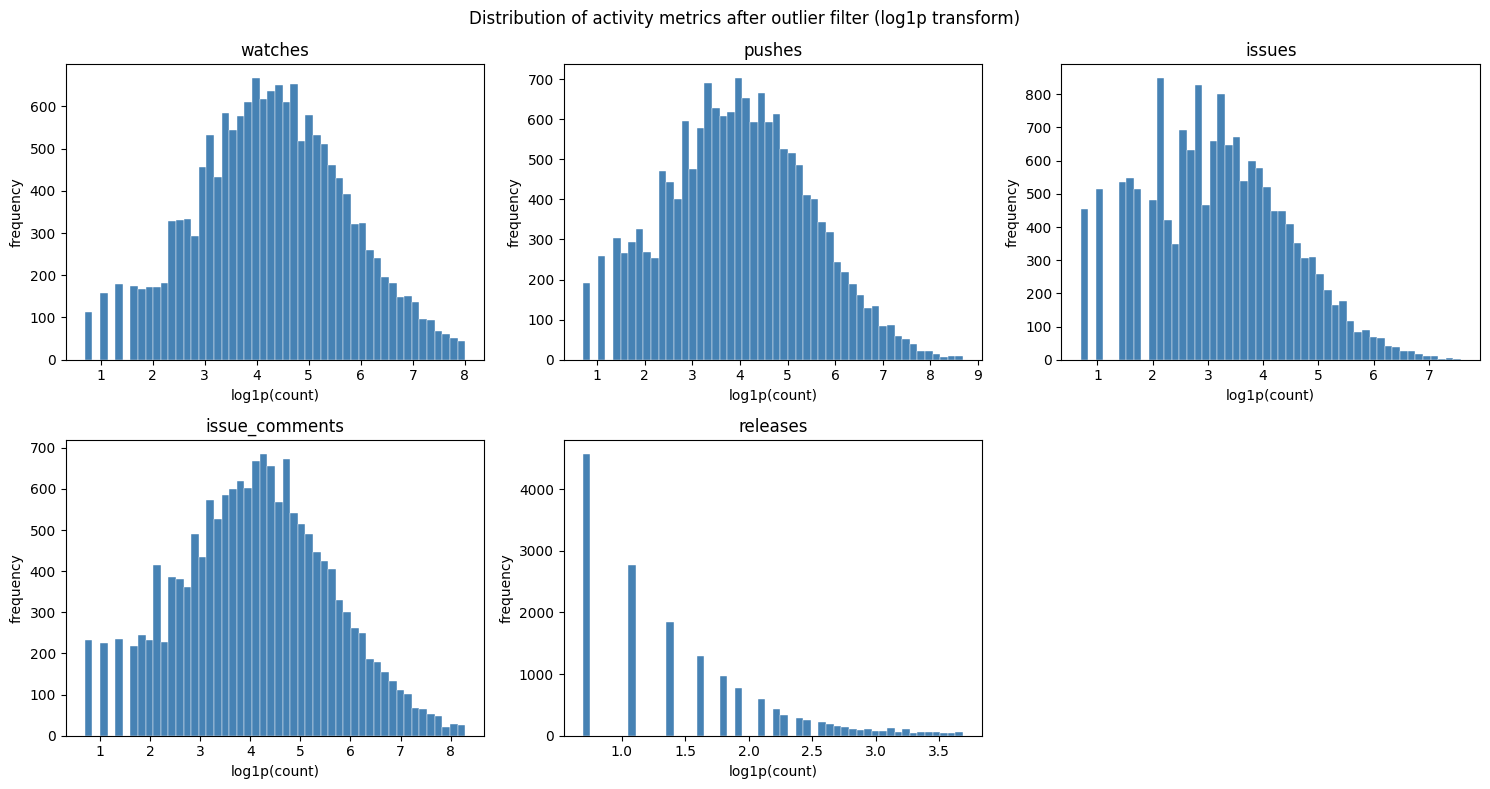

In [140]:
normal_activity = activity[
    (activity['watches'] < 3000) &
    (activity['pushes'] < 6000) &
    (activity['issues'] < 2000) &
    (activity['issue_comments'] < 4000) &
    (activity['releases'] < 40) &
    (activity['watches'] > 0) &
    (activity['pushes'] > 0) &
    (activity['issues'] > 0) &
    (activity['issue_comments'] > 0) &
    (activity['releases'] > 0)
]

print("Number of normal-activity repos:", len(normal_activity))
normal_activity[['watches','pushes','issues', 'issue_comments', 'releases']].describe()

import matplotlib.pyplot as plt
import numpy as np

features = ['watches', 'pushes', 'issues', 'issue_comments', 'releases']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(features):
    ax = axes.flat[i]
    x = np.log1p(normal_activity[col].astype(float))
    ax.hist(x, bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
    ax.set_title(col)
    ax.set_xlabel("log1p(count)")
    ax.set_ylabel("frequency")
axes.flat[-1].axis("off")
fig.suptitle("Distribution of activity metrics after outlier filter (log1p transform)")
plt.tight_layout()
plt.show()

### Seasonality Check

We verify whether the seasonal split (winter-spring vs summer-autumn) is preserved and balanced.

In [141]:
activity['season'].value_counts()

season
winter_spring    64066
summer_autumn    35934
Name: count, dtype: int64

In [142]:
activity.groupby('season')[['watches','pushes','issues', 'issue_comments', 'releases']].median()

,watches,pushes,issues,issue_comments,releases
season,,,,,
summer_autumn,26.0,4.0,1.0,3.0,0.0
winter_spring,28.0,3.0,1.0,2.0,0.0


### Repository Visibility

We analyze the proportion of public vs non-public repositories.

In [143]:
activity['public'].value_counts(normalize=True)

public
True    1.0
Name: proportion, dtype: Float64

### Distribution of Forks and Pull Requests

We analyze distributions of forks and pull requests separately to understand their spread and skewness.

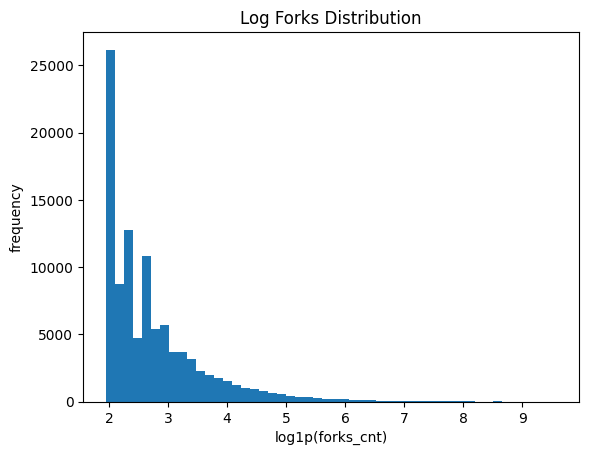

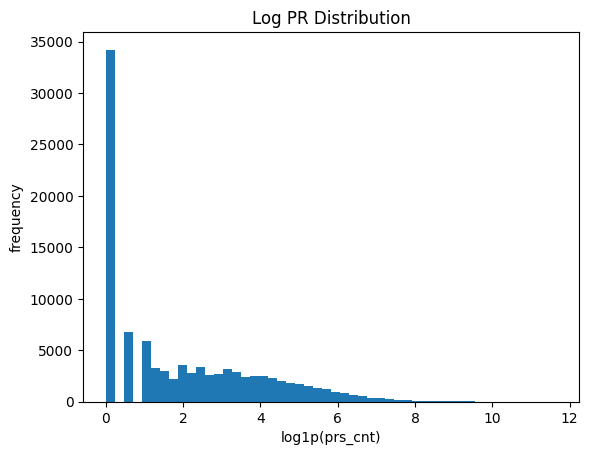

In [144]:
import numpy as np

fork_pr['forks_cnt'] = fork_pr['forks'].apply(len)
fork_pr['prs_cnt'] = fork_pr['prs'].apply(len)

plt.hist(np.log1p(fork_pr['forks_cnt']), bins=50)
plt.title("Log Forks Distribution")
plt.xlabel("log1p(forks_cnt)")
plt.ylabel("frequency")
plt.show()

plt.hist(np.log1p(fork_pr['prs_cnt']), bins=50)
plt.title("Log PR Distribution")
plt.xlabel("log1p(prs_cnt)")
plt.ylabel("frequency")
plt.show()

### Repositories with Forks but No PRs

We compute how many repositories have forks but no pull requests.

In [145]:
no_pr = (fork_pr['forks_cnt'] > 0) & (fork_pr['prs_cnt'] == 0)

print("Count:", no_pr.sum())
print("Share:", no_pr.mean())

Count: 34226
Share: 0.34226


### Multiple Forks by Same User

We check whether users create multiple forks for the same repository.

In [146]:
import pandas as pd

forks_exploded = fork_pr.explode('forks')
forks_exploded['user'] = forks_exploded['forks'].apply(lambda x: x['user_login'] if pd.notnull(x) else None)

forks_exploded.groupby(['repo_name','user']).size().describe()

count    2.749261e+06
mean     1.084652e+00
std      1.291533e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.010900e+04
dtype: float64

We analyze how often users create multiple forks of the same repository.

In [147]:
forks_exploded = fork_pr.explode('forks')
forks_exploded['user'] = forks_exploded['forks'].apply(lambda x: x['user_login'] if pd.notnull(x) else None)

user_repo_counts = forks_exploded.groupby(['repo_name','user']).size()

multi_forks = user_repo_counts[user_repo_counts > 1]

print("Repos with repeated forks:", multi_forks.reset_index()['repo_name'].nunique())
print("Total repeated fork cases:", len(multi_forks))
print("Average repeats:", multi_forks.mean())

Repos with repeated forks: 25603
Total repeated fork cases: 77840
Average repeats: 3.9898509763617676


In [148]:
prs_exploded = fork_pr.explode('prs')
prs_exploded['user'] = prs_exploded['prs'].apply(lambda x: x['user_login'] if pd.notnull(x) else None)

user_repo_pr = prs_exploded.groupby(['repo_name','user']).size()
multi_prs = user_repo_pr[user_repo_pr > 1]

print("Repos with repeated PRs:", multi_prs.reset_index()['repo_name'].nunique())
print("Average PR repeats:", multi_prs.mean())

Repos with repeated PRs: 45374
Average PR repeats: 21.586567270145544


### Temporal Distribution of Events

We analyze how forks and pull requests are distributed over time (monthly).

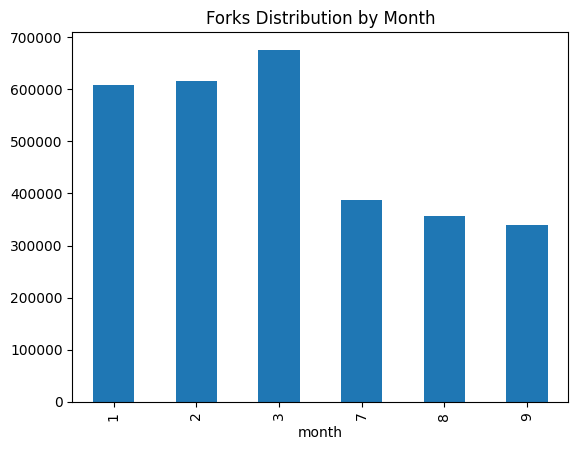

In [149]:
forks_exploded['time'] = forks_exploded['forks'].apply(lambda x: x['event_time'] if pd.notnull(x) else None)
forks_exploded['month'] = pd.to_datetime(forks_exploded['time']).dt.month

forks_exploded['month'].value_counts().sort_index().plot(kind='bar')
plt.title("Forks Distribution by Month")
plt.show()

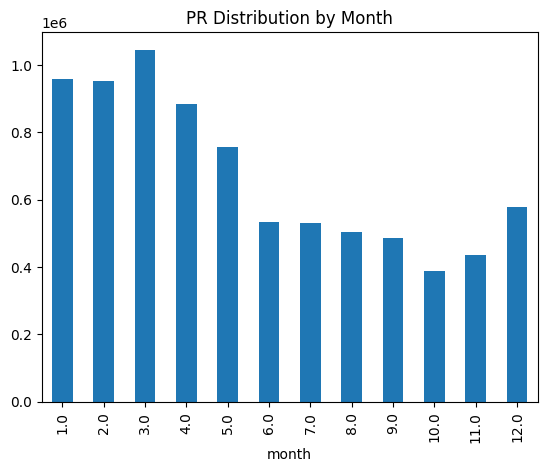

In [150]:
prs_exploded = fork_pr.explode('prs')
prs_exploded['time'] = prs_exploded['prs'].apply(lambda x: x['event_time'] if pd.notnull(x) else None)
prs_exploded['month'] = pd.to_datetime(prs_exploded['time']).dt.month

prs_exploded['month'].value_counts().sort_index().plot(kind='bar')
plt.title("PR Distribution by Month")
plt.show()

### Activity vs Fork Behavior

We explore the relationship between repository activity and number of forks.

/tmp/ipykernel_17975/3692961140.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = y.groupby(bins).median().dropna()
/tmp/ipykernel_17975/3692961140.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = y.groupby(bins).median().dropna()
/tmp/ipykernel_17975/3692961140.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = y.groupby(bins).median().dropna()
/tmp/ipykernel_17975/3692961140.py:17: Futu

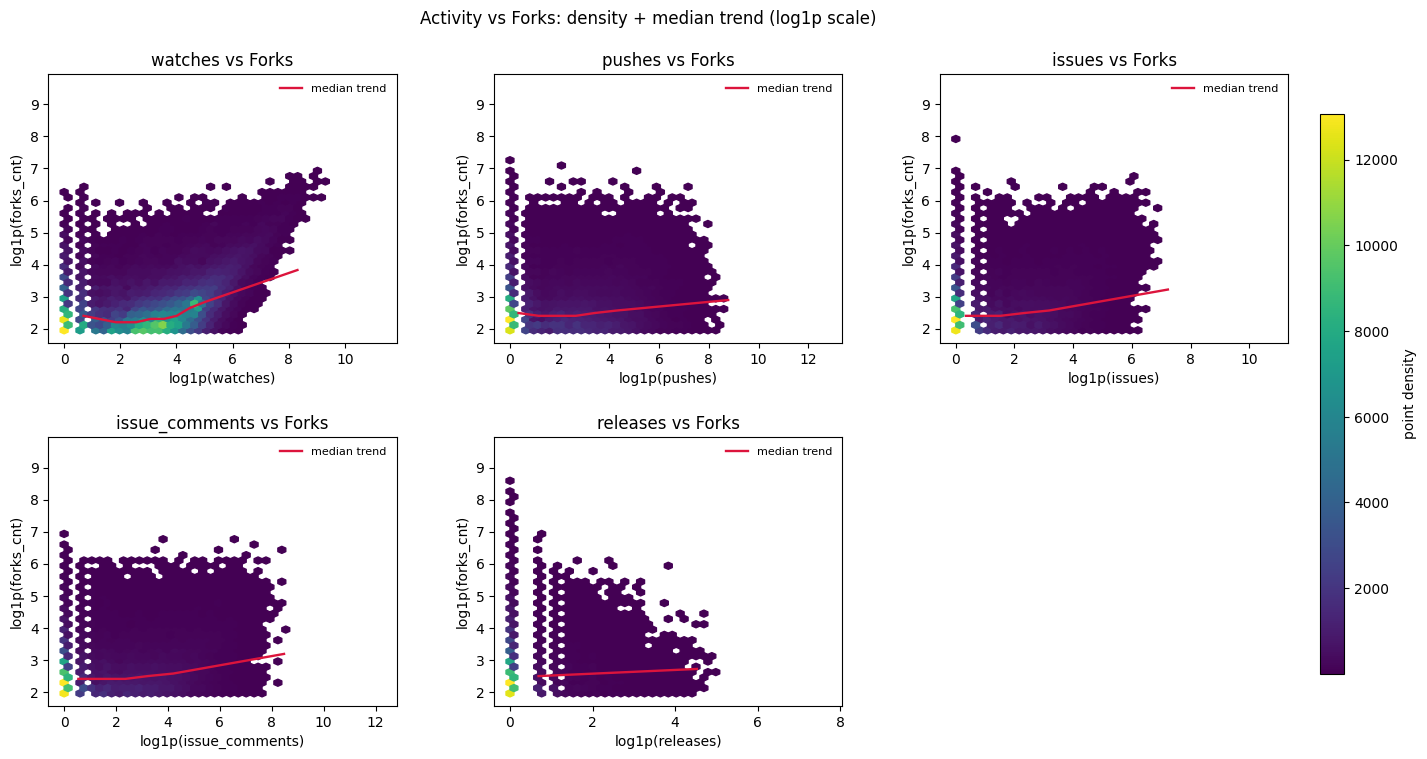

In [151]:
import numpy as np
import pandas as pd

merged = activity.merge(fork_pr, on=['repo_name', 'season'], how='inner', validate='one_to_one')
features = ['watches', 'pushes', 'issues', 'issue_comments', 'releases']


def plot_density_with_trend(df, x_col, y_col, y_label, ax):
    x = np.log1p(df[x_col].astype(float))
    y = np.log1p(df[y_col].astype(float))

    hb = ax.hexbin(x, y, gridsize=40, mincnt=5, cmap='viridis')

    q = np.unique(np.quantile(x, np.linspace(0, 1, 11)))
    if len(q) > 2:
        bins = pd.cut(x, bins=q, include_lowest=True, duplicates='drop')
        trend = y.groupby(bins).median().dropna()
        centers = [interval.mid for interval in trend.index]
        ax.plot(centers, trend.values, color='crimson', linewidth=1.7, label='median trend')
        ax.legend(frameon=False, fontsize=8)

    ax.set_title(f"{x_col} vs {y_label}")
    ax.set_xlabel(f"log1p({x_col})")
    ax.set_ylabel(f"log1p({y_col})")
    return hb


fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, feature in enumerate(features):
    hb = plot_density_with_trend(merged, feature, 'forks_cnt', 'Forks', axes.flat[i])

axes.flat[-1].axis('off')
fig.subplots_adjust(right=0.9, top=0.9, wspace=0.28, hspace=0.35)
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(hb, cax=cax)
cbar.set_label('point density')
fig.suptitle('Activity vs Forks: density + median trend (log1p scale)')
plt.show()

/tmp/ipykernel_17975/3692961140.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = y.groupby(bins).median().dropna()
/tmp/ipykernel_17975/3692961140.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = y.groupby(bins).median().dropna()
/tmp/ipykernel_17975/3692961140.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = y.groupby(bins).median().dropna()
/tmp/ipykernel_17975/3692961140.py:17: Futu

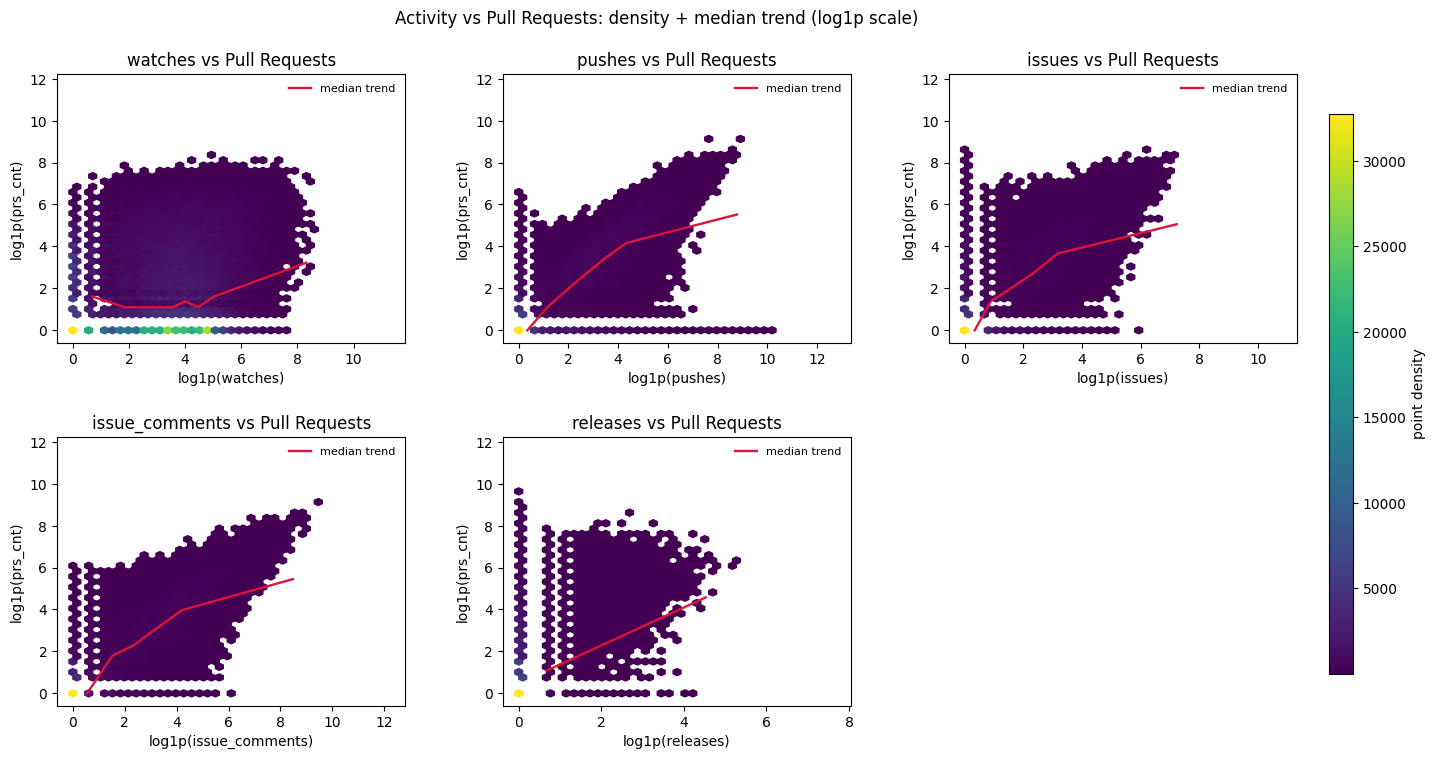

In [152]:
features = ['watches', 'pushes', 'issues', 'issue_comments', 'releases']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, feature in enumerate(features):
    hb = plot_density_with_trend(merged, feature, 'prs_cnt', 'Pull Requests', axes.flat[i])

axes.flat[-1].axis('off')
fig.subplots_adjust(right=0.9, top=0.9, wspace=0.28, hspace=0.35)
cax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
cbar = fig.colorbar(hb, cax=cax)
cbar.set_label('point density')
fig.suptitle('Activity vs Pull Requests: density + median trend (log1p scale)')
plt.show()

/tmp/ipykernel_17975/2291911506.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = y.groupby(bins).median().dropna()
/tmp/ipykernel_17975/2291911506.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = y.groupby(bins).median().dropna()


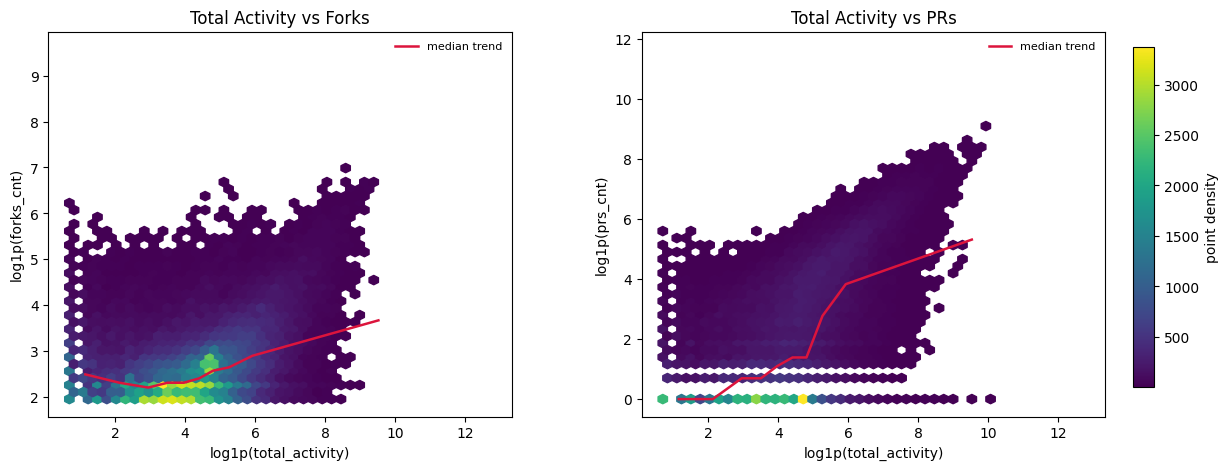

In [153]:
import numpy as np
import pandas as pd

merged['total_activity'] = (
    merged['watches'] +
    merged['pushes'] +
    merged['issues'] +
    merged['issue_comments'] +
    merged['releases']
)


def plot_total_activity_density(y_col, title, ax):
    plot_df = merged[['total_activity', y_col]].astype(float).replace([np.inf, -np.inf], np.nan).dropna()

    x = np.log1p(plot_df['total_activity'])
    y = np.log1p(plot_df[y_col])

    hb = ax.hexbin(x, y, gridsize=45, mincnt=5, cmap='viridis')

    q = np.unique(np.quantile(x, np.linspace(0, 1, 11)))
    if len(q) > 2:
        bins = pd.cut(x, bins=q, include_lowest=True, duplicates='drop')
        trend = y.groupby(bins).median().dropna()
        centers = [interval.mid for interval in trend.index]
        ax.plot(centers, trend.values, color='crimson', linewidth=1.8, label='median trend')
        ax.legend(frameon=False, fontsize=8)

    ax.set_title(title)
    ax.set_xlabel('log1p(total_activity)')
    ax.set_ylabel(f'log1p({y_col})')
    return hb


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hb1 = plot_total_activity_density('forks_cnt', 'Total Activity vs Forks', axes[0])
hb2 = plot_total_activity_density('prs_cnt', 'Total Activity vs PRs', axes[1])

fig.subplots_adjust(right=0.88, wspace=0.28)
cax = fig.add_axes([0.90, 0.17, 0.015, 0.68])
cbar = fig.colorbar(hb2, cax=cax)
cbar.set_label('point density')
plt.show()

In [154]:
fork_pr['pr_per_fork'] = fork_pr['prs_cnt'] / (fork_pr['forks_cnt'])

merged = activity.merge(fork_pr, on=['repo_name','season'])

corr_with_target = merged[['watches','pushes','issues','issue_comments','releases','pr_per_fork']].corr()

print(corr_with_target['pr_per_fork'].sort_values(ascending=False))

pr_per_fork       1.000000
issue_comments    0.213205
pushes            0.137040
issues            0.082955
releases          0.071771
watches          -0.010566
Name: pr_per_fork, dtype: float64


/tmp/ipykernel_17975/3167749137.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = y.groupby(bins).median().dropna()


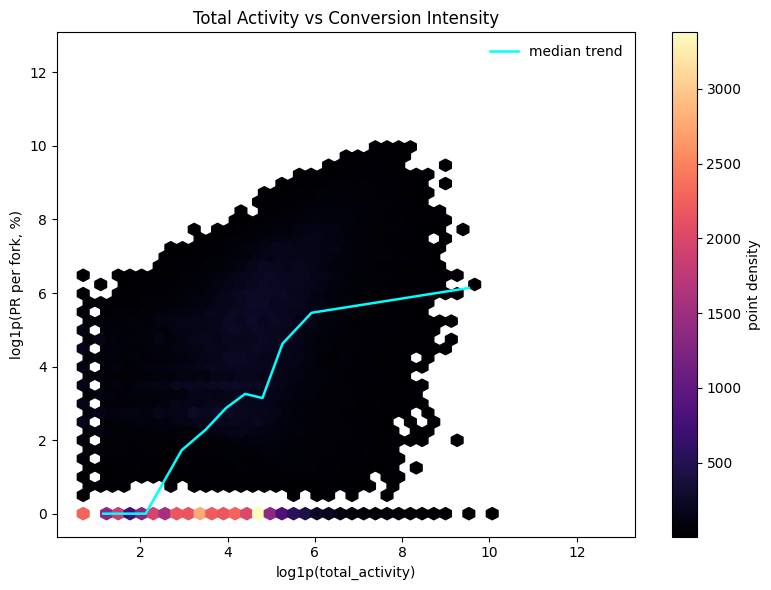

In [155]:
merged['total_activity'] = (
    merged['watches']
    + merged['pushes']
    + merged['issues']
    + merged['issue_comments']
    + merged['releases']
)

conv = 100 * merged['prs_cnt'] / merged['forks_cnt'].replace(0, np.nan)
plot_df = pd.DataFrame({
    'total_activity': merged['total_activity'].astype(float),
    'pr_per_fork_pct': conv.astype(float)
}).replace([np.inf, -np.inf], np.nan).dropna()

x = np.log1p(plot_df['total_activity'])
y = np.log1p(plot_df['pr_per_fork_pct'])

plt.figure(figsize=(8, 6))
hb = plt.hexbin(x, y, gridsize=45, mincnt=5, cmap='magma')

q = np.unique(np.quantile(x, np.linspace(0, 1, 11)))
if len(q) > 2:
    bins = pd.cut(x, bins=q, include_lowest=True, duplicates='drop')
    trend = y.groupby(bins).median().dropna()
    centers = [interval.mid for interval in trend.index]
    plt.plot(centers, trend.values, color='cyan', linewidth=1.8, label='median trend')
    plt.legend(frameon=False)

cbar = plt.colorbar(hb)
cbar.set_label('point density')
plt.xlabel('log1p(total_activity)')
plt.ylabel('log1p(PR per fork, %)')
plt.title('Total Activity vs Conversion Intensity')
plt.tight_layout()
plt.show()

In [156]:
merged[['watches','pushes','issues','issue_comments', 'releases', 'forks_cnt','prs_cnt']].describe()

,watches,pushes,issues,issue_comments,releases,forks_cnt,prs_cnt
count,100000.0,100000.0,100000.0,100000.0,100000.0,100000.000000,100000.000000
mean,120.74381,86.50863,21.31685,78.83938,1.95909,29.819910,80.579060
std,676.692394,1359.363454,240.586278,971.744721,22.006616,156.692666,840.303601
min,0.0,0.0,0.0,0.0,0.0,6.000000,0.000000
25%,6.0,0.0,0.0,0.0,0.0,7.000000,0.000000
50%,27.0,4.0,1.0,2.0,0.0,11.000000,3.000000
75%,87.0,28.0,9.0,24.0,0.0,20.000000,29.000000
max,79049.0,340799.0,48592.0,199042.0,2143.0,14513.000000,115874.000000


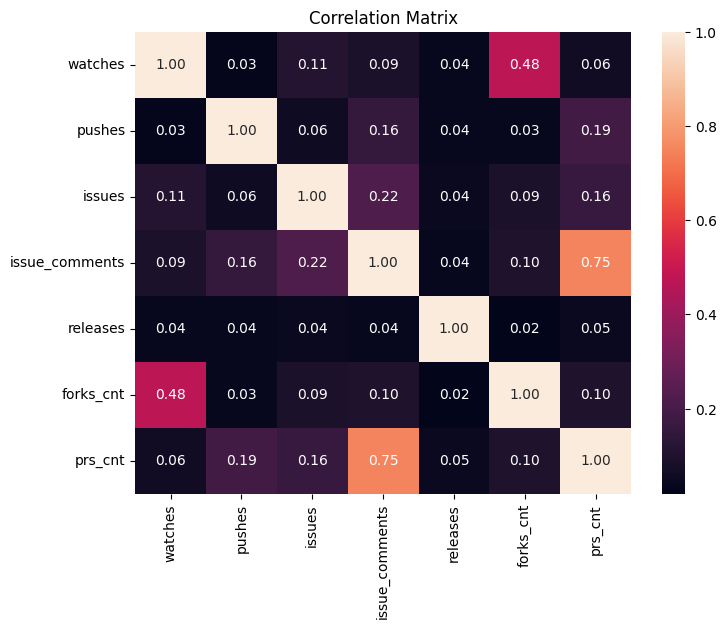

In [157]:
import seaborn as sns

corr = merged[['watches','pushes','issues','issue_comments','releases','forks_cnt','prs_cnt']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

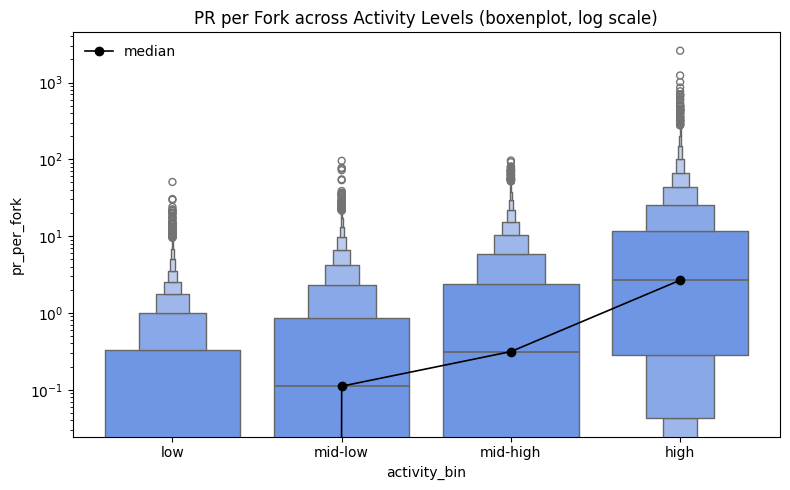

In [158]:
merged['activity_bin'] = pd.qcut(merged['total_activity'], q=4, labels=['low', 'mid-low', 'mid-high', 'high'])
merged['pr_per_fork'] = merged['prs_cnt'] / merged['forks_cnt'].replace(0, np.nan)
import seaborn as sns

plot_df = merged[['activity_bin', 'pr_per_fork']].replace([np.inf, -np.inf], np.nan).dropna()

plt.figure(figsize=(8, 5))
ax = sns.boxenplot(
    x='activity_bin',
    y='pr_per_fork',
    data=plot_df,
    k_depth='proportion',
    linewidth=1,
    color='#5B8FF9'
)

med = plot_df.groupby('activity_bin', observed=True)['pr_per_fork'].median().reindex(['low', 'mid-low', 'mid-high', 'high'])
ax.plot(range(len(med)), med.values, marker='o', color='black', linewidth=1.2, label='median')

plt.yscale('log')
plt.xlabel('activity_bin')
plt.ylabel('pr_per_fork')
plt.title('PR per Fork across Activity Levels (boxenplot, log scale)')
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

### Fork vs Pull Request Relationship

We compare the number of forks and pull requests per repository.

In [159]:
fork_pr['forks_cnt'] = fork_pr['forks'].apply(len)
fork_pr['prs_cnt'] = fork_pr['prs'].apply(len)

fork_pr[['forks_cnt','prs_cnt']].describe()

,forks_cnt,prs_cnt
count,100000.000000,100000.000000
mean,29.819910,80.579060
std,156.692666,840.303601
min,6.000000,0.000000
25%,7.000000,0.000000
50%,11.000000,3.000000
75%,20.000000,29.000000
max,14513.000000,115874.000000


We estimate the ratio between pull requests and forks to understand repository engagement.

In [160]:
fork_pr['pr_per_fork'] = fork_pr['prs_cnt'] / (fork_pr['forks_cnt'])

fork_pr['pr_per_fork'].describe()

count    100000.000000
mean          3.981780
std          18.740600
min           0.000000
25%           0.000000
50%           0.230769
75%           2.000000
max        2595.371429
Name: pr_per_fork, dtype: float64

In [161]:
fork_pr['bucket'] = pd.qcut(fork_pr['pr_per_fork'], q=5, duplicates='drop')
fork_pr.groupby('bucket')['pr_per_fork'].describe()

/tmp/ipykernel_17975/672785386.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fork_pr.groupby('bucket')['pr_per_fork'].describe()


,count,mean,std,min,25%,50%,75%,max
bucket,,,,,,,,
"(-0.001, 0.087]",40066.0,0.007304,0.019668,0.000000,0.000000,0.000000,0.000000,0.086957
"(0.087, 0.571]",20076.0,0.266209,0.138501,0.087336,0.142857,0.235294,0.363636,0.571429
"(0.571, 3.119]",19858.0,1.517344,0.697845,0.573248,0.903381,1.368421,2.000000,3.117647
"(3.119, 2595.371]",20000.0,18.120476,38.783613,3.122449,5.000000,8.637626,18.227504,2595.371429


n=100,000 | median=0.231 | p90=8.637 | p95=18.227 | p99=58.223 | max=2595.371


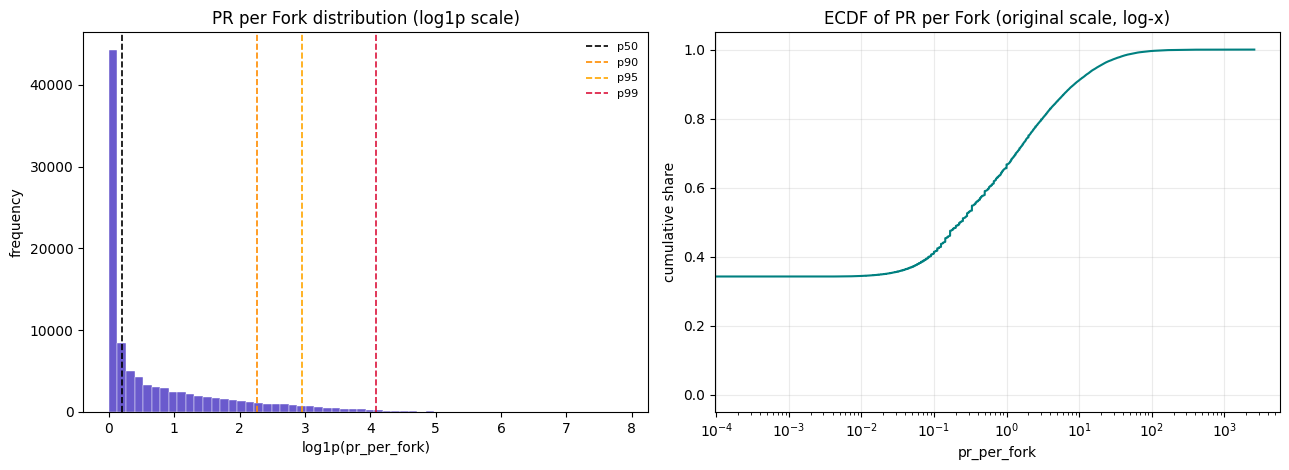

In [162]:
import numpy as np
import matplotlib.pyplot as plt

s = fork_pr['pr_per_fork'].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
log_s = np.log1p(s)

q50, q90, q95, q99 = np.quantile(s, [0.50, 0.90, 0.95, 0.99])
print(f"n={len(s):,} | median={q50:.3f} | p90={q90:.3f} | p95={q95:.3f} | p99={q99:.3f} | max={s.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].hist(log_s, bins=60, color='slateblue', edgecolor='white', linewidth=0.3)
for q, color, name in [(q50, 'black', 'p50'), (q90, 'darkorange', 'p90'), (q95, 'orange', 'p95'), (q99, 'crimson', 'p99')]:
    axes[0].axvline(np.log1p(q), color=color, linestyle='--', linewidth=1.2, label=name)
axes[0].set_title('PR per Fork distribution (log1p scale)')
axes[0].set_xlabel('log1p(pr_per_fork)')
axes[0].set_ylabel('frequency')
axes[0].legend(frameon=False, fontsize=8)

x_sorted = np.sort(s.values)
y_ecdf = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
axes[1].plot(x_sorted, y_ecdf, color='teal', linewidth=1.5)
axes[1].set_xscale('log')
axes[1].set_title('ECDF of PR per Fork (original scale, log-x)')
axes[1].set_xlabel('pr_per_fork')
axes[1].set_ylabel('cumulative share')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## **Verify Data Quality**

### Missing Values
We check for missing values in both datasets to understand data completeness and potential gaps.

In [163]:
print("Activity missing values:")
print(activity.isnull().sum())

print("\nFork/PR missing values:")
print(fork_pr.isnull().sum())

Activity missing values:
repo_name         0
season            0
repo_url          0
public            0
watches           0
pushes            0
issues            0
issue_comments    0
releases          0
dtype: int64

Fork/PR missing values:
repo_name      0
season         0
forks          0
prs            0
forks_cnt      0
prs_cnt        0
pr_per_fork    0
bucket         0
dtype: int64


We inspect missing values inside nested fork and pull request structures.

In [164]:
forks_exploded = fork_pr.explode('forks')
prs_exploded = fork_pr.explode('prs')

print("Forks null entries:", forks_exploded['forks'].isnull().sum())
print("PRs null entries:", prs_exploded['prs'].isnull().sum())

Forks null entries: 0
PRs null entries: 34226


Note that 39348 is the number of repositories without Pull Requests, meaning there are no missing values.

### Duplicate Records
We perform a deeper duplicate analysis beyond full-row duplication.

In [165]:
print("Duplicate repo-season pairs (activity):")
print(activity.duplicated(subset=['repo_name','season']).sum())

print("Duplicate repo-season pairs (fork_pr):")
print(fork_pr.duplicated(subset=['repo_name','season']).sum())

Duplicate repo-season pairs (activity):
0
Duplicate repo-season pairs (fork_pr):
0


### Data Consistency
We verify that both datasets contain the same set of repositories.

In [166]:
activity_repos = set(activity['repo_name'])
fork_repos = set(fork_pr['repo_name'])

print("Repos only in activity:", len(activity_repos - fork_repos))
print("Repos only in fork_pr:", len(fork_repos - activity_repos))

Repos only in activity: 0
Repos only in fork_pr: 0


In [167]:
forks_exploded['time'] = forks_exploded['forks'].apply(lambda x: x['event_time'] if pd.notnull(x) else None)

print("Fork time range:")
print(forks_exploded['time'].min(), forks_exploded['time'].max())

prs_exploded['time'] = prs_exploded['prs'].apply(lambda x: x['event_time'] if pd.notnull(x) else None)

print("PRs time range:")
print(prs_exploded['time'].min(), prs_exploded['time'].max())

Fork time range:
2025-01-01 00:00:02+00:00 2025-09-30 23:59:58+00:00
PRs time range:
2025-01-01 00:00:00+00:00 2025-12-31 23:59:53+00:00


In [168]:
print("Activity seasons:", activity['season'].value_counts())
print("Fork/PR seasons:", fork_pr['season'].value_counts())

Activity seasons: season
winter_spring    64066
summer_autumn    35934
Name: count, dtype: int64
Fork/PR seasons: season
winter_spring    64066
summer_autumn    35934
Name: count, dtype: int64


We check for duplicate features and complete dependencies.

                 watches    pushes    issues  issue_comments  releases
watches         1.000000  0.029577  0.111961        0.087865  0.035140
pushes          0.029577  1.000000  0.057001        0.155331  0.035566
issues          0.111961  0.057001  1.000000        0.220855  0.042027
issue_comments  0.087865  0.155331  0.220855        1.000000  0.037911
releases        0.035140  0.035566  0.042027        0.037911  1.000000


<Axes: >

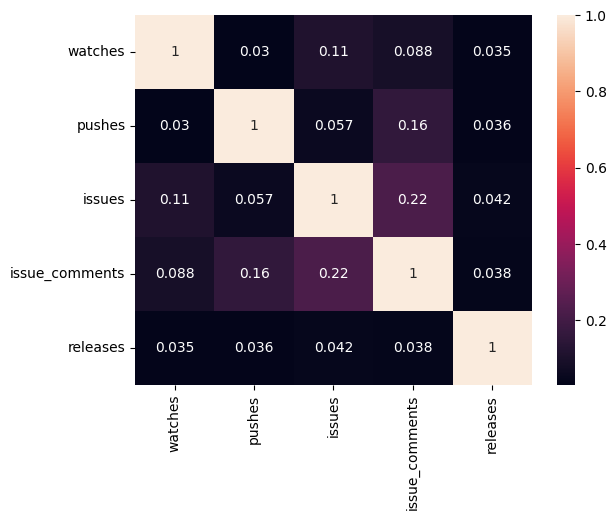

In [169]:
import seaborn as sns

corr = activity[['watches','pushes','issues','issue_comments','releases']].corr()
print(corr)

sns.heatmap(corr, annot=True)

In [170]:
# Target
fork_pr['pr_per_fork'] = fork_pr['prs_cnt'] / (fork_pr['forks_cnt'])

# Merge
merged = activity.merge(fork_pr, on=['repo_name','season'])

# Correlation with target
corr_with_target = merged[['watches','pushes','issues','issue_comments','releases','pr_per_fork']].corr()

print(corr_with_target['pr_per_fork'].sort_values(ascending=False))

pr_per_fork       1.000000
issue_comments    0.213205
pushes            0.137040
issues            0.082955
releases          0.071771
watches          -0.010566
Name: pr_per_fork, dtype: float64


Consistency check: the number of PRs should not significantly exceed the number of forks.

In [171]:
suspicious = fork_pr[
    (fork_pr['forks_cnt'] > 0) &
    (fork_pr['prs_cnt'] > fork_pr['forks_cnt'] * 10)
]

print("Highly suspicious repos:", len(suspicious))
suspicious[['forks_cnt','prs_cnt']].describe()

Highly suspicious repos: 8859


,forks_cnt,prs_cnt
count,8859.000000,8859.000000
mean,19.244723,619.240885
std,44.043975,2714.929482
min,6.000000,61.000000
25%,7.000000,140.000000
50%,10.000000,257.000000
75%,17.000000,514.000000
max,1780.000000,115874.000000


Checking Event Density

In [172]:
forks_exploded['date'] = pd.to_datetime(forks_exploded['time']).dt.date

activity_spikes = forks_exploded.groupby(['repo_name','date']).size()

print("Extreme daily spikes:")
print(activity_spikes[activity_spikes > 100].describe())

Extreme daily spikes:
count     825.000000
mean      271.275152
std       396.878039
min       101.000000
25%       118.000000
50%       150.000000
75%       230.000000
max      4318.000000
dtype: float64


### Invalid or Suspicious Values
We check for negative or logically inconsistent values in activity metrics.

In [173]:
print("Negative values check:")

print("Watches < 0:", (activity['watches'] < 0).sum())
print("Pushes < 0:", (activity['pushes'] < 0).sum())
print("Issues < 0:", (activity['issues'] < 0).sum())
print("Issue comments < 0:", (activity['issue_comments'] < 0).sum())
print("Releases < 0:", (activity['releases'] < 0).sum())

Negative values check:
Watches < 0: 0
Pushes < 0: 0
Issues < 0: 0
Issue comments < 0: 0
Releases < 0: 0


count    100000.000000
mean          3.624928
std          17.223761
min           0.000000
50%           0.222222
90%           7.900000
95%          16.571429
99%          52.750549
max        2523.277778
Name: pr_per_fork, dtype: float64


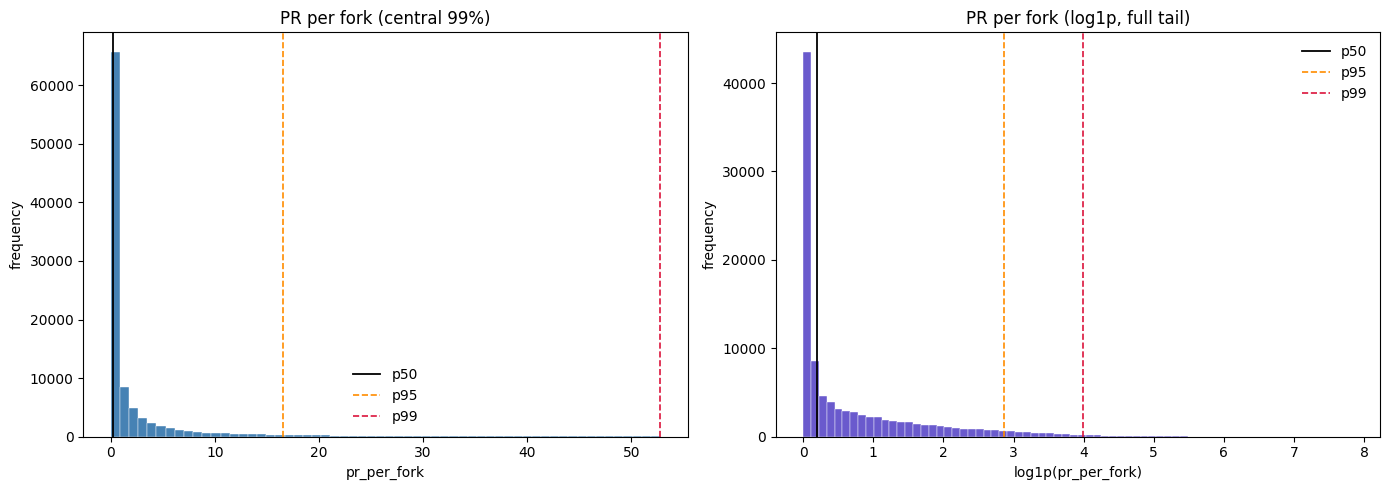

In [174]:
import numpy as np
import matplotlib.pyplot as plt

fork_pr['pr_per_fork'] = fork_pr['prs_cnt'] / (fork_pr['forks_cnt'] + 1)

s = fork_pr['pr_per_fork'].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
print(s.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

q95 = s.quantile(0.95)
q99 = s.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Central mass in original scale (up to p99)
axes[0].hist(s[s <= q99], bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[0].axvline(s.median(), color='black', linewidth=1.3, label='p50')
axes[0].axvline(q95, color='darkorange', linestyle='--', linewidth=1.2, label='p95')
axes[0].axvline(q99, color='crimson', linestyle='--', linewidth=1.2, label='p99')
axes[0].set_title('PR per fork (central 99%)')
axes[0].set_xlabel('pr_per_fork')
axes[0].set_ylabel('frequency')
axes[0].legend(frameon=False)

# 2) Full distribution in log1p scale (keeps tail visible)
axes[1].hist(np.log1p(s), bins=70, color='slateblue', edgecolor='white', linewidth=0.3)
axes[1].axvline(np.log1p(s.median()), color='black', linewidth=1.3, label='p50')
axes[1].axvline(np.log1p(q95), color='darkorange', linestyle='--', linewidth=1.2, label='p95')
axes[1].axvline(np.log1p(q99), color='crimson', linestyle='--', linewidth=1.2, label='p99')
axes[1].set_title('PR per fork (log1p, full tail)')
axes[1].set_xlabel('log1p(pr_per_fork)')
axes[1].set_ylabel('frequency')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

### Extreme Values
We examine extremely large values that may indicate anomalies or skewed data.

In [175]:
activity[['watches','pushes','issues', 'issue_comments', 'releases']].quantile([0.95, 0.99, 0.999])

,watches,pushes,issues,issue_comments,releases
0.950,400.0,269.05,80.0,263.0,7.0
0.990,1536.02,1192.02,301.0,1169.01,33.0
0.999,7814.032,7404.009,1376.029,6779.099,170.001
